In [41]:
import numpy as np
import yfinance as yf
import pandas as pd
from datetime import date 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats


Matplotlib is building the font cache; this may take a moment.


In [60]:


TICKER_A = "GC=F"
TICKER_B = "SI=F"

START = "1979-01-01"
END = date.today().strftime("%Y-%m-%d")

LOOKBACK_WINDOW = 30

data = yf.download([TICKER_A, TICKER_B], start=START, end=END, group_by="column")

#df = data[[TICKER_A]].dropna()

print(data)

[*********************100%***********************]  2 of 2 completed

Price             Close                    High                     Low  \
Ticker             GC=F       SI=F         GC=F       SI=F         GC=F   
Date                                                                      
2000-08-30   273.899994   4.930000   273.899994   4.950000   273.899994   
2000-08-31   278.299988   5.003000   278.299988   5.045000   274.799988   
2000-09-01   277.000000   5.004000   277.000000   5.035000   277.000000   
2000-09-05   275.799988   4.998000   275.799988   5.005000   275.799988   
2000-09-06   274.200012   4.983000   274.200012   5.000000   274.200012   
...                 ...        ...          ...        ...          ...   
2026-06-15  4328.000000  70.066002  4362.000000  70.066002  4269.100098   
2026-06-16  4330.899902  69.899002  4345.799805  69.899002  4309.500000   
2026-06-17  4358.899902  70.695999  4377.000000  70.949997  4296.000000   
2026-06-18  4224.100098  66.254997  4323.200195  66.254997  4223.700195   
2026-06-22  4181.899902  

In [61]:
print(type(data))
data.head()
data.columns

<class 'pandas.DataFrame'>


MultiIndex([( 'Close', 'GC=F'),
            ( 'Close', 'SI=F'),
            (  'High', 'GC=F'),
            (  'High', 'SI=F'),
            (   'Low', 'GC=F'),
            (   'Low', 'SI=F'),
            (  'Open', 'GC=F'),
            (  'Open', 'SI=F'),
            ('Volume', 'GC=F'),
            ('Volume', 'SI=F')],
           names=['Price', 'Ticker'])

In [62]:
close_df = data.loc[:, 'Close']
close_df.head()
close_df.columns

Index(['GC=F', 'SI=F'], dtype='str', name='Ticker')

In [63]:
# Ratio 


close_df["Ratio"] = close_df[TICKER_B] / close_df[TICKER_A]

# calculate 30 day rolling statistics 
close_df["Rolling_Mean"] = close_df["Ratio"].rolling(window=LOOKBACK_WINDOW).mean()
close_df["Rolling_Std"] = close_df["Ratio"].rolling(window=LOOKBACK_WINDOW).std()

# Calculate the Rolling Z-Score
close_df["Z_Score"] = (close_df["Ratio"] - close_df["Rolling_Mean"]) / close_df["Rolling_Std"]


close_df.head()

Ticker,GC=F,SI=F,Ratio,Rolling_Mean,Rolling_Std,Z_Score
Date,,,,,,
2000-08-30,273.899994,4.930,0.017999,NaN,NaN,NaN
2000-08-31,278.299988,5.003,0.017977,NaN,NaN,NaN
2000-09-01,277.000000,5.004,0.018065,NaN,NaN,NaN
2000-09-05,275.799988,4.998,0.018122,NaN,NaN,NaN
2000-09-06,274.200012,4.983,0.018173,NaN,NaN,NaN


In [64]:
final_df = close_df[[TICKER_A, TICKER_B, "Ratio", "Z_Score"]].dropna()

print("\n--- Latest 10 Trading Days (Gold/Silver Ratio) ---")
print(final_df.tail(10).to_string())


--- Latest 10 Trading Days (Gold/Silver Ratio) ---
Ticker             GC=F       SI=F     Ratio   Z_Score
Date                                                  
2026-06-08  4335.899902  68.425003  0.015781 -1.270746
2026-06-09  4260.000000  65.094002  0.015280 -1.812133
2026-06-10  4108.200195  64.598999  0.015724 -1.229933
2026-06-11  4090.300049  63.884998  0.015619 -1.347176
2026-06-12  4215.000000  67.859001  0.016099 -0.762829
2026-06-15  4328.000000  70.066002  0.016189 -0.639143
2026-06-16  4330.899902  69.899002  0.016140 -0.698680
2026-06-17  4358.899902  70.695999  0.016219 -0.610801
2026-06-18  4224.100098  66.254997  0.015685 -1.215924
2026-06-22  4181.899902  65.527000  0.015669 -1.156599


In [65]:
print(f"Total rows in final_df: {len(final_df)}")
print(f"Date range: {final_df.index.min()} to {final_df.index.max()}")

Total rows in final_df: 6358
Date range: 2000-10-11 00:00:00 to 2026-06-22 00:00:00


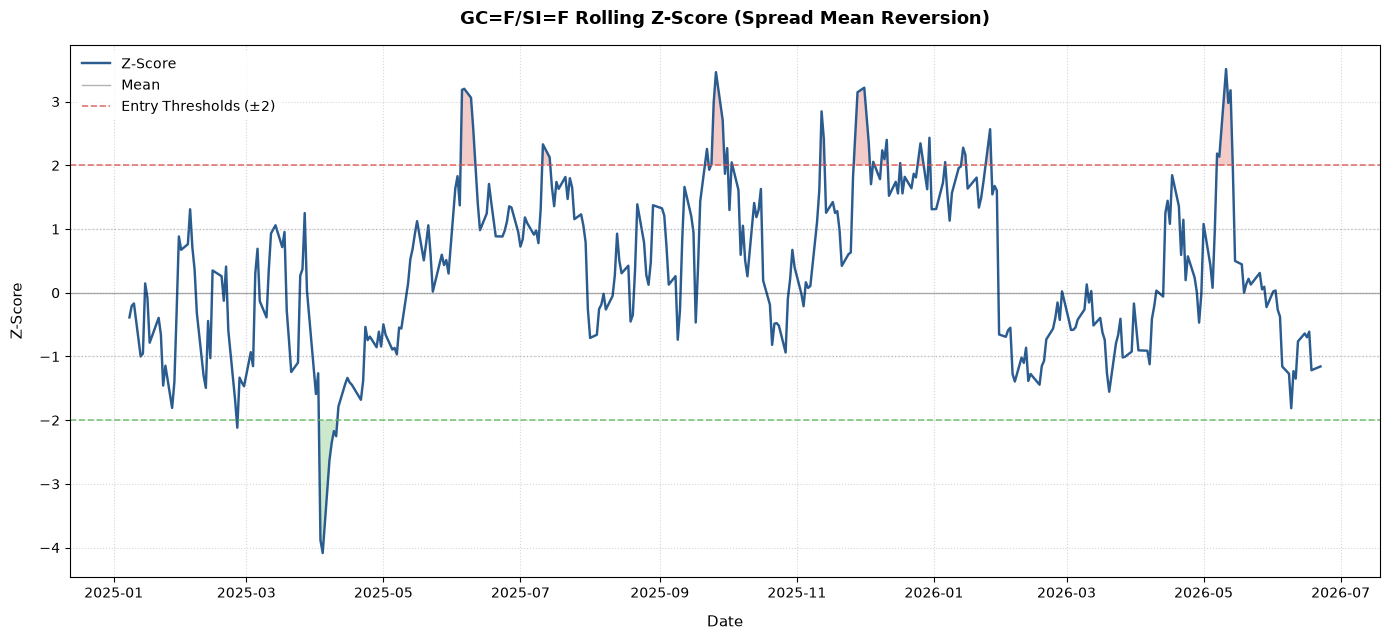

In [66]:

import matplotlib.pyplot as plt

close_df = final_df.tail(365)

plt.figure(figsize=(14, 6.5))  # Slightly wider aspect ratio for a cleaner timeline

# Plot the rolling Z-Score
plt.plot(
    close_df.index,
    close_df["Z_Score"],
    color="#2b5c8f",
    linewidth=1.75,
    label="Z-Score"
)

# Trading thresholds
plt.axhline(0, color="black", linestyle="-", alpha=0.3, linewidth=1, label="Mean")
plt.axhline(2, color="#d9534f", linestyle="--", alpha=0.8, linewidth=1.2, label="Entry Thresholds (±2)")
plt.axhline(-2, color="#5cb85c", linestyle="--", alpha=0.8, linewidth=1.2)
plt.axhline(1, color="gray", linestyle=":", alpha=0.4, linewidth=1)
plt.axhline(-1, color="gray", linestyle=":", alpha=0.4, linewidth=1)

z = close_df["Z_Score"]

# Shade "Short the Spread" territory (Z >= 2)
# Shading from the +2 threshold up to the actual Z-score
plt.fill_between(
    close_df.index,
    2,
    z,
    where=(z >= 2),
    facecolor="#d9534f",
    alpha=0.3,
    interpolate=True
)

# Shade "Long the Spread" territory (Z <= -2)
# Shading from the -2 threshold down to the actual Z-score
plt.fill_between(
    close_df.index,
    -2,
    z,
    where=(z <= -2),
    facecolor="#5cb85c",
    alpha=0.3,
    interpolate=True
)

# Formatting
plt.title(f"{TICKER_A}/{TICKER_B} Rolling Z-Score (Spread Mean Reversion)", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Date", fontsize=11, labelpad=10)
plt.ylabel("Z-Score", fontsize=11, labelpad=10)

# Clean up legend (combining the ±2 lines under a single label)
plt.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()

plt.show()
